# TS4

#### Rey Tomás 
#### APS

# Introducción

Un estimador es una herramienta de la estadística que nos permite, a partir de un grupo de datos obtenidos de manera experimental, aproximar parámetros que caracterizan a un sistema. En este trabajo, analizaremos las dos cualidades más importantes de una señal senoidal: Su amplitud y frecuencia.

Nuestra señal senoidal de entrada tendrá la forma 
$$x(n)=a_0sen(\Omega_1n)+n_a(n)(1)$$ 

Donde $a_0=\sqrt2$ para que la señal esté normalizada y
$$\Omega_1=\Omega_0+f_r\frac{2\pi}{N}(2)$$

Con $\Omega_0=\frac{\pi}{2}$. La frecuencia $\Omega_1$ y el rudio $n_a(n)$ tienen en realidad un comportamiento estocástico donde
$$f_r\sim\mathcal{U}(-2,2)$$
$$n_a\sim\mathcal{N}(0,\sigma^2)$$

Los estimadores se calcularán según las ecuaciones
$$\hat{\Omega}_1^i = \arg \max_{f} \{ |X_w^i(\Omega)| \}(3)$$
$$\hat{a}_1^i = |X_w^i(\Omega_0)| = |\mathcal{F}\{ x(n) \cdot w_i(n) \}|(4)$$

Para poder tener estimadores útiles, los procesos serán repetidos un número R=200 veces.

El estimador de frecuencia sale de observar los datos de amplitud de la señal centrándome únicamente en $\Omega_0$, mientras que el de la frecuencia se obtiene observando el máximo de cada una de las 200 realizaciones.

In [2]:
"""
Created on Wed Sep  9 19:20:32 2026

@author: tomas
"""
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal.windows as window

Defino una función que calculará los estimadores y los datos básicos para el análisis temporal y espectral

In [3]:
def main_func(w,SNR):
    #Empiezo por definir la señal
    R=200#Numero de realizaciones
    N=1000
    fs=1000
    n=(np.arange(0,N)).reshape(1,N)#Sirve como vector de cantidad de realizaciones y de tiempo
    P_ruido=1/(10**(SNR/10))
    
        
    a0=np.sqrt(2)
    sigma_0=np.pi/2
    fr=np.random.uniform(low=-2,high=2,size=(R,1))#Genero la frecuencia de dist. uniforme
    na=np.random.normal(0,np.sqrt(P_ruido),size=(R,N))#Genero el ruido con dist. normal
    sigma_1=sigma_0+fr*(2*np.pi/N)
    x_n=a0*np.sin(sigma_1*n)+na#Señal original
    x_w=x_n*w#señal ventaneada
    
    X_f=(2/N)*np.abs(np.fft.fft(x_w,axis=1))
    k=np.arange(N)*(fs/N)     
    
    #Estimador de amplitud
    a_1=X_f[:,250]
    
        
    #Estimador de frecuencia
    omega=2*np.pi*np.argmax(X_f[:,:N//2],axis=1)/N
    
    return(n,x_n,k,X_f,a_1,omega)

La función de debajo me permite ver, en un primer lugar, como el ventaneo ocurre en el tiempo y luego se muestra el espectro de potencia de las señales ventaneadas en escala dB. Estos gráficos no eran necesarios y los hice mayormente por curiosidad y para ver paso a paso como era el proceso de ventaneo. 

In [4]:
def fun_graficadora(n,x_n,k,X_f,w,SNR,name):
    R=200
    x_w=x_n*w#señal ventaneada
    fs=1000
    
    fig,ax=plt.subplots(3,1,figsize=(10,8))
    #señal original
    for i in range(R):
        ax[0].plot(n[0,:],x_n[i,:],':') 
    ax[0].set_title(f'Señal original, SNR={SNR}')
    ax[0].set_xlabel('Tiempo [s]')
    ax[0].set_ylabel('Amplitud [V]')
    #ventana
    ax[1].plot(n[0,:],w,color='red')
    ax[1].set_title(f'{name}')
    ax[1].set_xlabel('Tiempo [s]')
    #señal + ventana
    for i in range(R):
        ax[2].plot(n[0, :], x_w[i, :], ':')
    ax[2].set_ylabel('Amplitud [V]')
    ax[2].set_xlabel('Tiempo [s]')
    ax[2].set_title(f'Señal original+{name}')
    plt.tight_layout()
    plt.show()


    #Potencia espectral de señales ventaneadas
    plt.figure()
    for i in range(R):
        plt.plot(k, 20*np.log10(X_f[i, :]),':')
    plt.xlim(0,fs/2)
    plt.xlabel('Frecuencia [hz]')
    plt.ylabel('Potencia[dB]')
    plt.title(f'Espectro de potencia de señal ventaneada por {name}')
    plt.show()    

    return()
N=1000


# Defino las ventanas que voy a usar

In [5]:
square=np.ones(N)
flattop=window.flattop(N)
blackmanharris=window.blackmanharris(N)
#Ventana exponencial: e^(-|n-center|/tau)
#Tau indica que tan rapido decaera mi ventana. c es el centro, que se encuentra por defecto en el medio de la longitud que le estoy dando a la ventana
#Propongo que quiero que en los bordes la señal caiga a un 10% del valor original. Para eso
#0.1=e^(-|n-center|/tau)
#de donde puedo despejar tau=-|n-center|/ln(0.1)
tau=-(N/2)/np.log(0.1)
exponencial=window.exponential(N,tau=tau)

# VENTANA CUADRADA


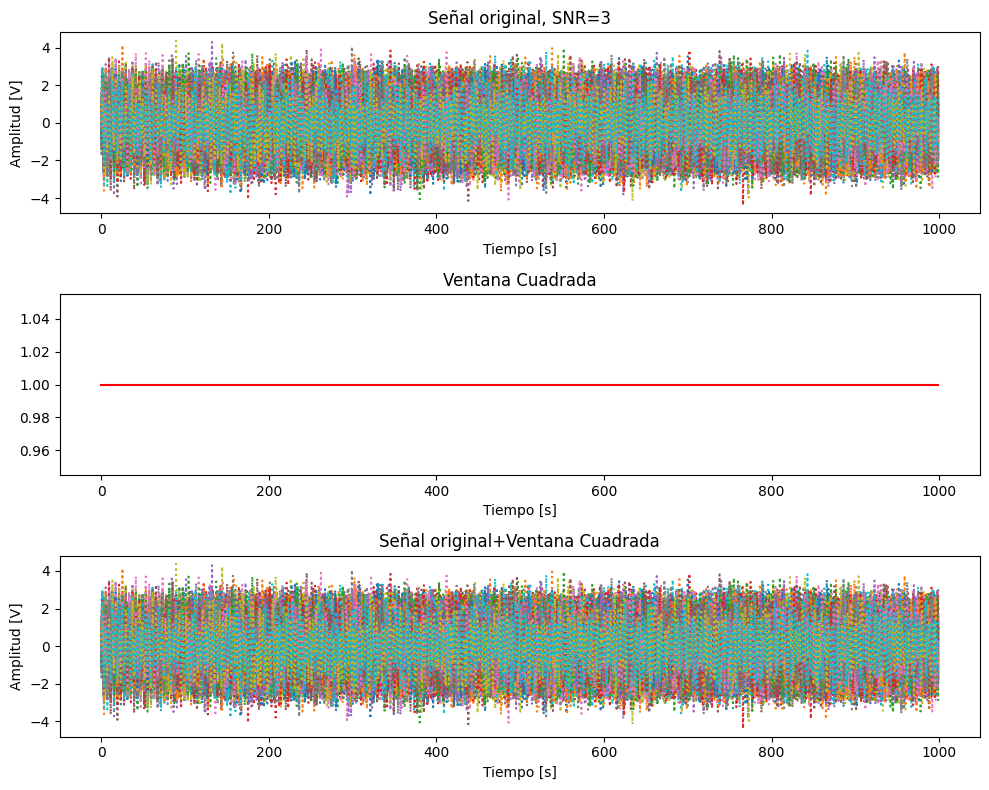

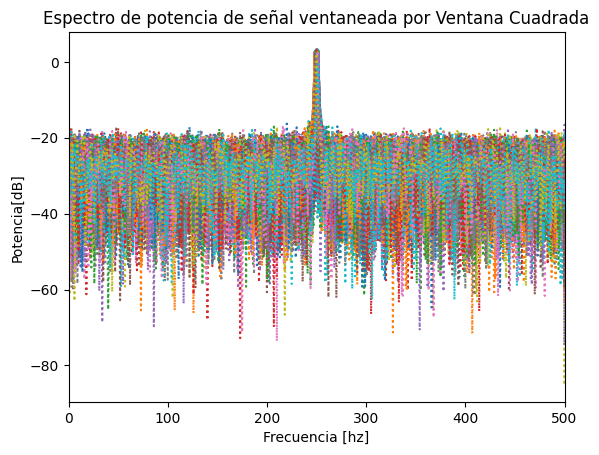

In [6]:
n_square,x_square,k_square,X_f_square,a_square,omega_square=main_func(square,SNR=3)
#Grafico del proceso de ventaneo
fun_graficadora(n_square,x_square,k_square,X_f_square,square,SNR='3',name='Ventana Cuadrada')
#Calculos de sesgo y varianza
var_a_square=np.var(a_square)
sesgo_a_square=np.mean(a_square)-np.sqrt(2)
var_omega_square=np.var(omega_square)
sesgo_omega_square=np.mean(omega_square)-np.pi/2

# VENTANA FLATTOP


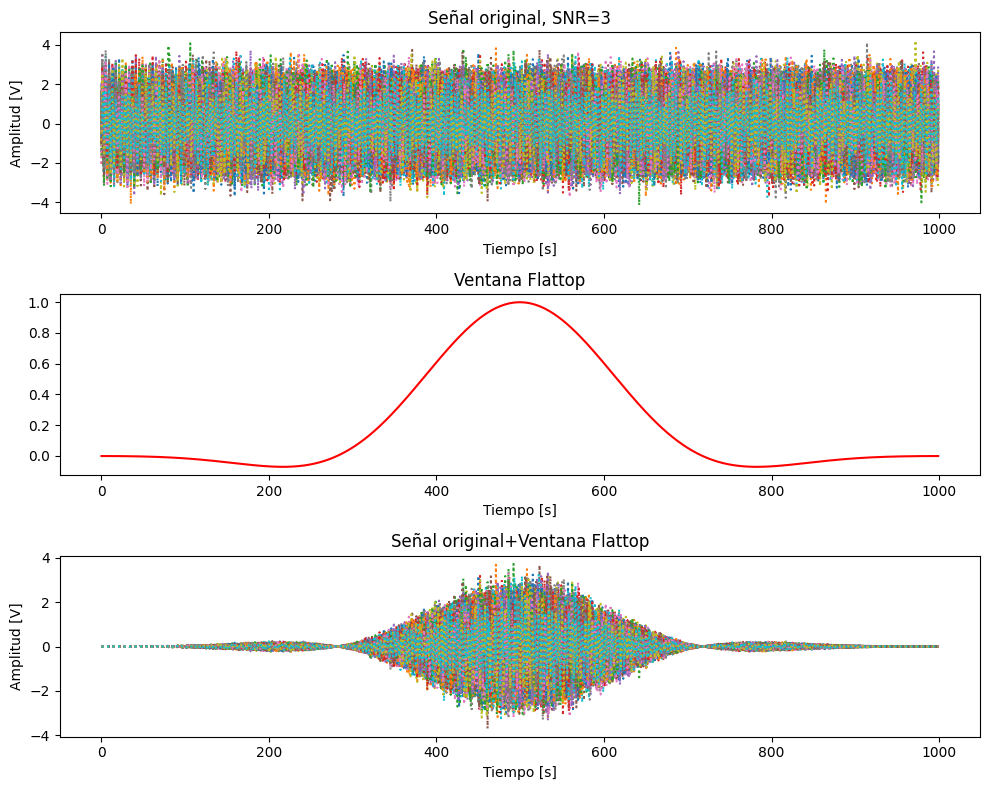

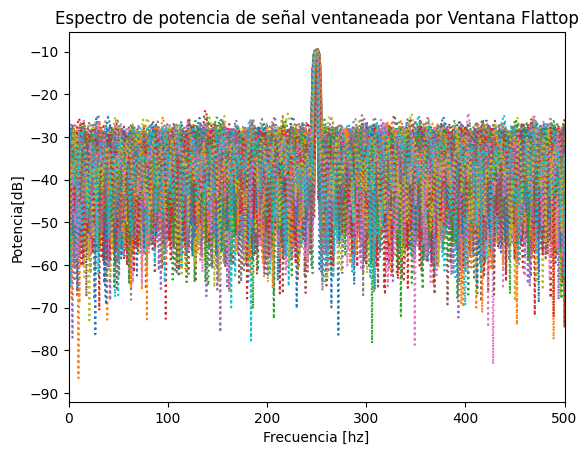

In [11]:
n_flattop,x_flattop,k_flattop,X_f_flattop,a_flattop,omega_flattop=main_func(flattop,SNR=3)
#Graficos del ventaneo
fun_graficadora(n_flattop,x_flattop,k_flattop,X_f_flattop,flattop,SNR='3',name='Ventana Flattop')
#Calculos de sesgo y varianza
var_a_flattop=np.var(a_flattop)
sesgo_a_flattop=np.mean(a_flattop)-np.sqrt(2)
var_omega_flattop=np.var(omega_flattop)
sesgo_omega_flattop=np.mean(omega_flattop)-np.pi/2

# VENTANA BLACKMANHARRIS


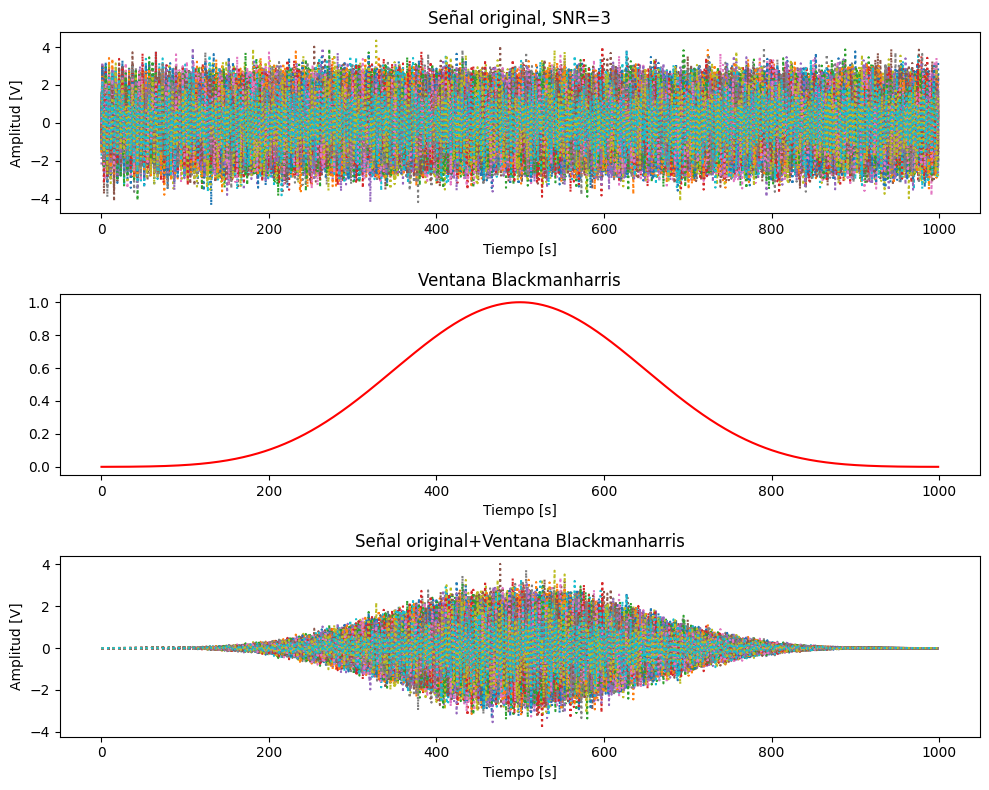

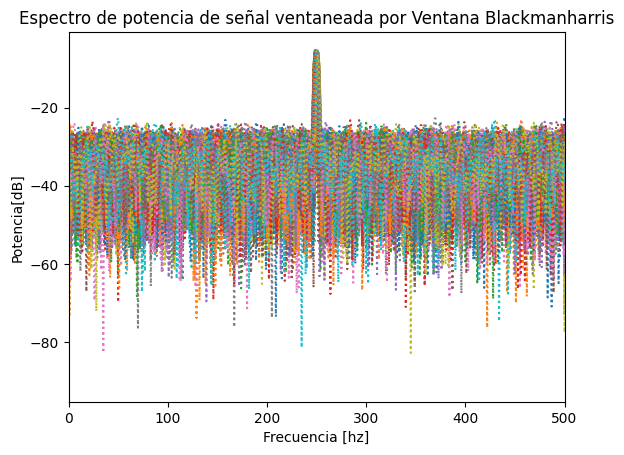

In [12]:
n_black,x_n_black,k_black,X_f_black,a_black,omega_black=main_func(blackmanharris,SNR=3)   
#Graficos de ventaneo
fun_graficadora(n_black,x_n_black,k_black,X_f_black,blackmanharris,SNR='3',name='Ventana Blackmanharris')
#Calculos de sesgo y varianza
var_a_black=np.var(a_black)
sesgo_a_black=np.mean(a_black)-np.sqrt(2)
var_omega_black=np.var(omega_black)
sesgo_omega_black=np.mean(omega_black)-np.pi/2

# VENTANA EXPONENCIAL


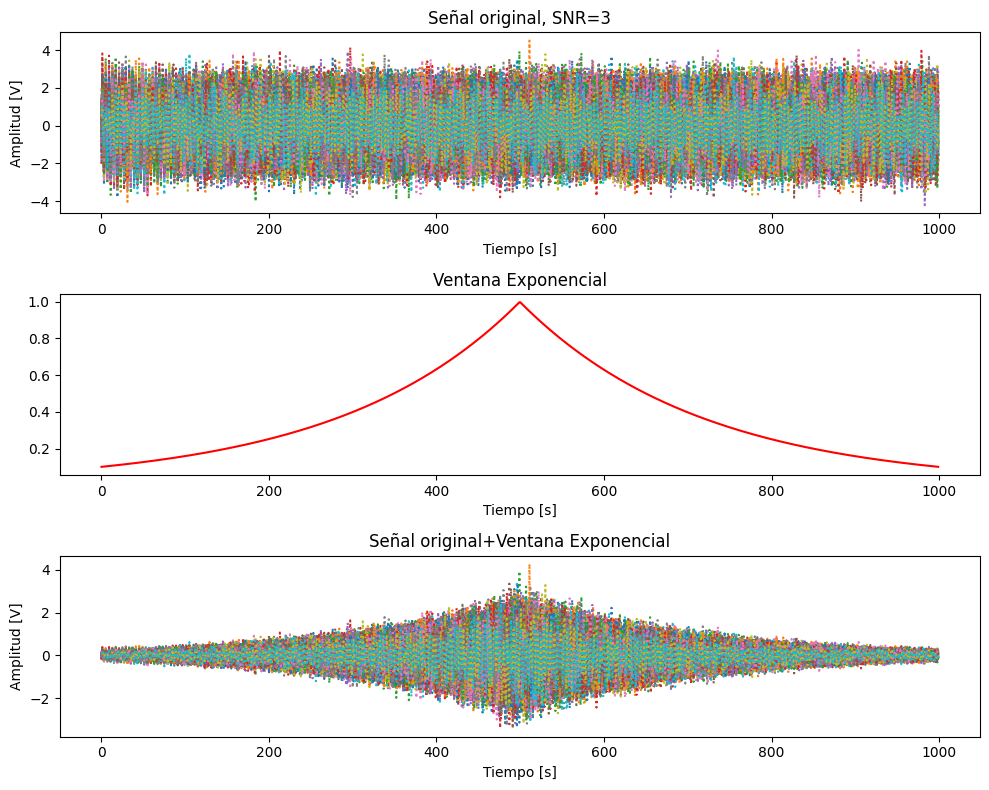

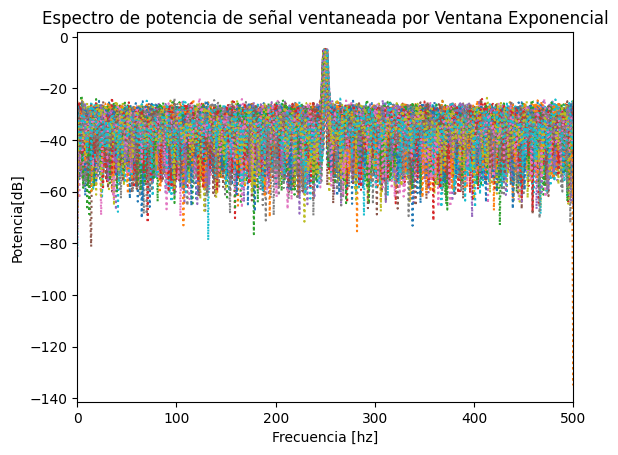

In [13]:
n_exp,x_n_exp,k_exp,X_f_exp,a_exp,omega_exp=main_func(exponencial,SNR=3)
#Grafico del ventaneo
fun_graficadora(n_exp,x_n_exp,k_exp,X_f_exp,exponencial,SNR='3',name='Ventana Exponencial')
#Calculo de sesgo y varianza
var_a_exp=np.var(a_exp)
sesgo_a_exp=np.mean(a_exp)-np.sqrt(2)
var_omega_exp=np.var(omega_exp)
sesgo_omega_exp=np.mean(omega_exp)-np.pi/2

# TABLA DE ESTIMADORES

In [17]:
print('\n\nEstimador de amplitud:')
print(f"{'':<14}         | {'s_a':^10}   | {'v_a':^10}")
print("-" * 49)
print(f"Ventana cuadrada       | {sesgo_a_square:^10.4e}  | {var_a_square:^10.4e}")
print(f"Ventana Flattop        | {sesgo_a_flattop:^10.4e}  | {var_a_flattop:^10.4e}")
print(f"Ventana Blackmanharris | {sesgo_a_black:^10.4e}  | {var_a_black:^10.4e}")
print(f"Ventana Exponencial    | {sesgo_a_exp:^10.4e}  | {var_a_exp:^10.4e}")
print('\n\nEstimador de frecuencia:')
print(f"{'':<14}         | {'s_omega':^10}   | {'v_omega':^10}")
print("-" * 49)
print(f"Ventana cuadrada       | {sesgo_omega_square:^10.4e}   | {var_omega_square:^10.4e}")
print(f"Ventana Flattop        | {sesgo_omega_flattop:^10.4e}  | {var_omega_flattop:^10.4e}")
print(f"Ventana Blackmanharris | {sesgo_omega_black:^10.4e}  | {var_omega_black:^10.4e}")
print(f"Ventana Exponencial    | {sesgo_omega_exp:^10.4e}  | {var_omega_exp:^10.4e}")



Estimador de amplitud:
                       |    s_a       |    v_a    
-------------------------------------------------
Ventana cuadrada       | -9.1549e-01  | 1.8839e-01
Ventana Flattop        | -1.1343e+00  | 1.1197e-03
Ventana Blackmanharris | -1.0730e+00  | 1.5528e-02
Ventana Exponencial    | -1.1178e+00  | 2.8401e-02


Estimador de frecuencia:
                       |  s_omega     |  v_omega  
-------------------------------------------------
Ventana cuadrada       | 7.8540e-04   | 6.1562e-05
Ventana Flattop        | -4.3982e-04  | 6.0603e-05
Ventana Blackmanharris | -8.4823e-04  | 5.1984e-05
Ventana Exponencial    | -4.0841e-04  | 4.9773e-05


Se puede observar que la varianza para el estimador de amplitud para todas las ventanas fue muy pequeña, con ordenes menores a 1. El mejor desempeño en este aspecto la tuvo la ventana flattop, con uno o dos ordenes de varianza menos que el resto. Por otro lado, el sesgo fue negativo y aproximadamente -1V para todas las ventanas usadas, lo que habla de que el valor esperado de mi distribución fue siempre alrededor de una unidad menor al valor esperado, por lo que se cometió sistemáticamente un error por defecto.

El estimador de frecuencia tuvo tanto varianza como sesgo similar para todas las ventanas, coincidiendo siempre en los ordenes de magnitud y demostrando ser un buen estimador sin importar la ventana. 

# HISTOGRAMAS

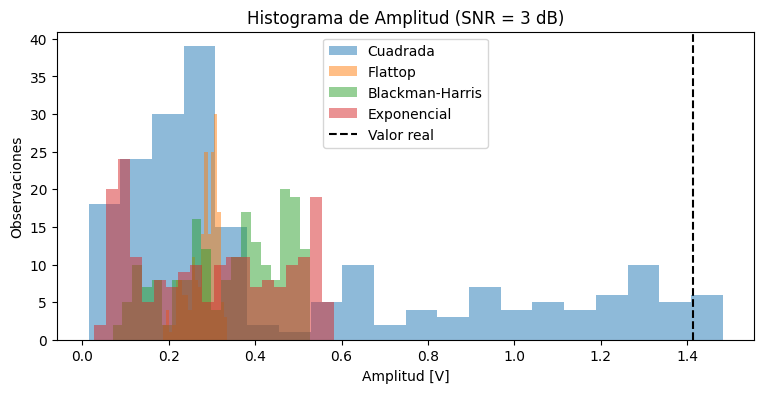

In [18]:
# Histograma de Amplitud
plt.figure(figsize=(9, 4))
plt.hist(a_square, bins=20, alpha=0.5, label='Cuadrada')
plt.hist(a_flattop, bins=20, alpha=0.5, label='Flattop')
plt.hist(a_black, bins=20, alpha=0.5, label='Blackman-Harris')
plt.hist(a_exp, bins=20, alpha=0.5, label='Exponencial')
plt.axvline(np.sqrt(2), color='black', linestyle='--', label='Valor real')
plt.title('Histograma de Amplitud (SNR = 3 dB)')
plt.xlabel('Amplitud [V]')
plt.ylabel('Observaciones')
plt.legend()
plt.show()

Este gráfico plasma lo discutido en las tablas de sesgo y varianza: La ventana flattop muestra el mejor desempeño ya que tiene todos sus valores alejados del teórico o real, pero muy juntos entre sí, lo que se ve como el pico naranja muy alto alrededor de 0.3V. Las ventanas blackman-harris y exponencial tuvieron un desempeño similar, con una peor varianza, y la peor de todas fue la cuadrada ya que está altamente sesgada y tiene mucha varianza entre realizaciones. Gráficamente se ve como todas estan un volt por debajo del valor esperado $\sqrt2$.

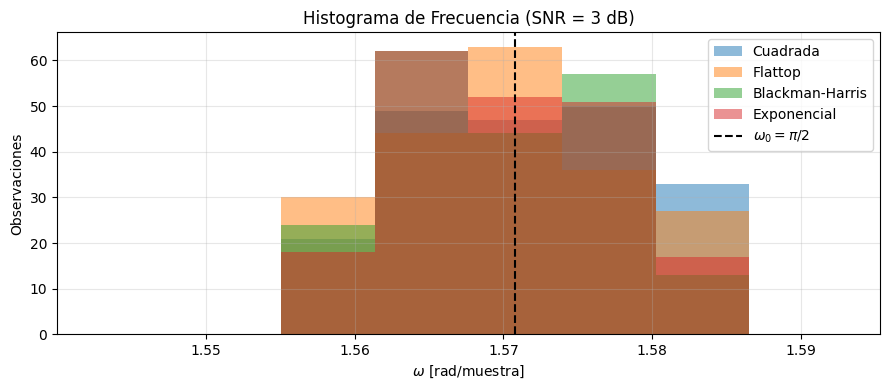

In [21]:
bines_k = np.arange(246, 255)
bines_omega = (bines_k - 0.5) * (2 * np.pi / N)#transformo los bins a unidades de frecuencia

plt.figure(figsize=(9, 4))
plt.hist(omega_square,  bins=bines_omega, linewidth=2, label='Cuadrada',alpha=0.5)
plt.hist(omega_flattop, bins=bines_omega, linewidth=2, label='Flattop',alpha=0.5)
plt.hist(omega_black,   bins=bines_omega, linewidth=2, label='Blackman-Harris',alpha=0.5)
plt.hist(omega_exp,     bins=bines_omega, linewidth=2, label='Exponencial',alpha=0.5)

plt.axvline(np.pi / 2, color='black', linestyle='--', label=r'$\omega_0 = \pi/2$')
plt.title('Histograma de Frecuencia (SNR = 3 dB)')
plt.xlabel(r'$\omega$ [rad/muestra]')
plt.ylabel('Observaciones')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Nuevamente, el histograma se condice con lo previsto en la tabla de valores. La varianza es muy similar para todas las venatanas, e incluso las "peores" observaciones no se alejaron más de 0.02 radianes del valor esperado 

# Repito, con ruido de SNR=10

In [22]:
n_square,x_square,k_square,X_f_square,a_square,omega_square=main_func(square,SNR=10)
#Calculos de sesgo y varianza
var_a_square=np.var(a_square)
sesgo_a_square=np.mean(a_square)-np.sqrt(2)
var_omega_square=np.var(omega_square)
sesgo_omega_square=np.mean(omega_square)-np.pi/2

n_flattop,x_flattop,k_flattop,X_f_flattop,a_flattop,omega_flattop=main_func(flattop,SNR=10)
#Calculos de sesgo y varianza
var_a_flattop=np.var(a_flattop)
sesgo_a_flattop=np.mean(a_flattop)-np.sqrt(2)
var_omega_flattop=np.var(omega_flattop)
sesgo_omega_flattop=np.mean(omega_flattop)-np.pi/2

n_black,x_n_black,k_black,X_f_black,a_black,omega_black=main_func(blackmanharris,SNR=10)   
#Calculos de sesgo y varianza
var_a_black=np.var(a_black)
sesgo_a_black=np.mean(a_black)-np.sqrt(2)
var_omega_black=np.var(omega_black)
sesgo_omega_black=np.mean(omega_black)-np.pi/2

n_exp,x_n_exp,k_exp,X_f_exp,a_exp,omega_exp=main_func(exponencial,SNR=10)
#Calculo de sesgo y varianza
var_a_exp=np.var(a_exp)
sesgo_a_exp=np.mean(a_exp)-np.sqrt(2)
var_omega_exp=np.var(omega_exp)
sesgo_omega_exp=np.mean(omega_exp)-np.pi/2

In [23]:
#=======================TABLA DE ESTIMADORES==============================================================
print('\n\nEstimador de amplitud:')
print(f"{'':<14}         | {'s_a':^10}  | {'v_a':^10}")
print("-" * 49)
print(f"Ventana cuadrada       | {sesgo_a_square:^10.4e} | {var_a_square:^10.4e}")
print(f"Ventana Flattop        | {sesgo_a_flattop:^10.4e} | {var_a_flattop:^10.4e}")
print(f"Ventana Blackmanharris | {sesgo_a_black:^10.4e} | {var_a_black:^10.4e}")
print(f"Ventana Exponencial    | {sesgo_a_exp:^10.4e} | {var_a_exp:^10.4e}")
print('\n\nEstimador de frecuencia:')
print(f"{'':<14}         | {'s_omega':^10}  | {'v_omega':^10}")
print("-" * 49)
print(f"Ventana cuadrada       | {sesgo_omega_square:^10.4e}   | {var_omega_square:^10.4e}")
print(f"Ventana Flattop        | {sesgo_omega_flattop:^10.4e}  | {var_omega_flattop:^10.4e}")
print(f"Ventana Blackmanharris | {sesgo_omega_black:^10.4e}  | {var_omega_black:^10.4e}")
print(f"Ventana Exponencial    | {sesgo_omega_exp:^10.4e}   | {var_omega_exp:^10.4e}")



Estimador de amplitud:
                       |    s_a      |    v_a    
-------------------------------------------------
Ventana cuadrada       | -8.9221e-01 | 2.1626e-01
Ventana Flattop        | -1.1346e+00 | 9.0751e-04
Ventana Blackmanharris | -1.0696e+00 | 1.5357e-02
Ventana Exponencial    | -1.1387e+00 | 3.2173e-02


Estimador de frecuencia:
                       |  s_omega    |  v_omega  
-------------------------------------------------
Ventana cuadrada       | -6.5973e-04   | 5.4637e-05
Ventana Flattop        | 1.0681e-03  | 5.4129e-05
Ventana Blackmanharris | 2.8274e-04  | 4.9071e-05
Ventana Exponencial    | 1.8850e-04   | 5.7603e-05


Los valores obtenidos son muy parecidos para la amplitud aunque ligeramente mejores para el estimador de frecuencia, en especial para su varianza

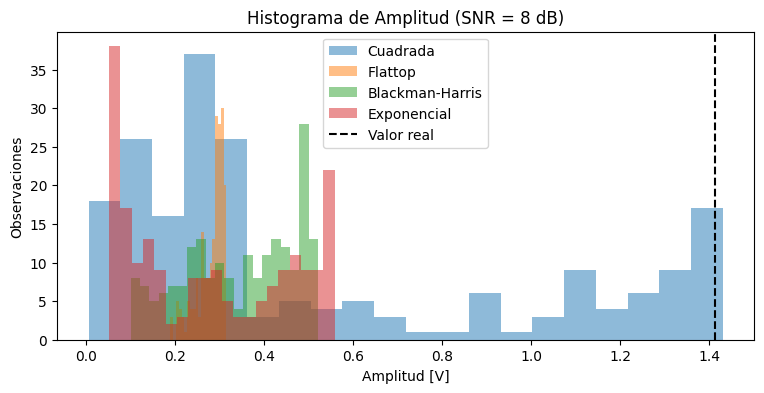

In [24]:
# Histograma de Amplitud
plt.figure(figsize=(9, 4))
plt.hist(a_square, bins=20, alpha=0.5, label='Cuadrada')
plt.hist(a_flattop, bins=20, alpha=0.5, label='Flattop')
plt.hist(a_black, bins=20, alpha=0.5, label='Blackman-Harris')
plt.hist(a_exp, bins=20, alpha=0.5, label='Exponencial')
plt.axvline(np.sqrt(2), color='black', linestyle='--', label='Valor real')
plt.title(f'Histograma de Amplitud (SNR = 8 dB)')
plt.xlabel('Amplitud [V]')
plt.ylabel('Observaciones')
plt.legend()
plt.show()

Este gráfico muestra una mayor concentración de valores para la flattop pero en rasgos generales se comporta igual

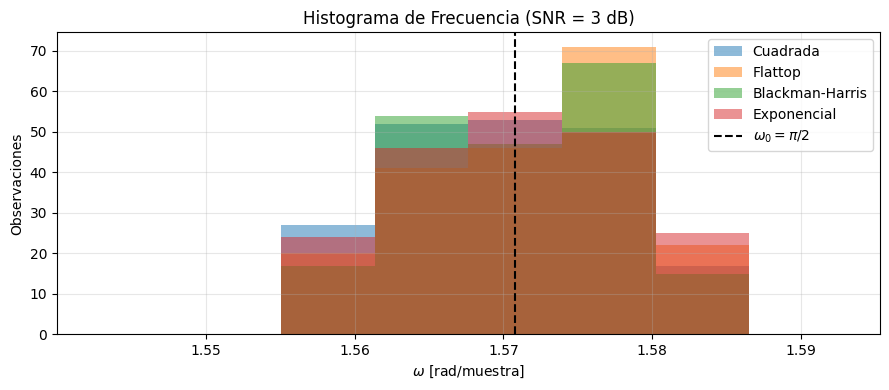

In [25]:
bines_k = np.arange(246, 255)
bines_omega = (bines_k - 0.5) * (2 * np.pi / N)

plt.figure(figsize=(9, 4))
plt.hist(omega_square,  bins=bines_omega, linewidth=2, label='Cuadrada',alpha=0.5)
plt.hist(omega_flattop, bins=bines_omega, linewidth=2, label='Flattop',alpha=0.5)
plt.hist(omega_black,   bins=bines_omega, linewidth=2, label='Blackman-Harris',alpha=0.5)
plt.hist(omega_exp,     bins=bines_omega, linewidth=2, label='Exponencial',alpha=0.5)

plt.axvline(np.pi / 2, color='black', linestyle='--', label=r'$\omega_0 = \pi/2$')
plt.title('Histograma de Frecuencia (SNR = 3 dB)')
plt.xlabel(r'$\omega$ [rad/muestra]')
plt.ylabel('Observaciones')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

La varianza es muy parecida para todos los tipos de ventana, y el sesgo mejoró ligeramente

# Conclusiones

El estimador de frecuencia usado demostró ser el mejor de los dos ya que estimó la frecuencia de la señal de manera consistente, con baja varianza y sesgo sin importar la ventana aplicada.

El estimador de amplitud no fue igual de consistente y varió mucho entre ventana y ventana. La ventana uniforme tuvo el peor desempeño y yo recomendaría su descarte si se quiere estimar la amplitud. La exponencial y la blackman-harris presentan un desempeño mejor aunque sigue habiendo un sesgo y varianza considerable. La flattop resultó ser la mejor ya que, por más de que sus valores estimados suelen caer bastante lejos del teórico, caen en un entorno pequeño de manera muy consistente (es decir, hay poca varianza), por lo que el efecto del sesgo puede ser corregido con un offset, por ejemplo, uno de +1V.

Aumentar el ruido no cambió notablemente el comportamiento de ninguno de los dos estimadores. Mejoraron ligeramente cuando el ruido disminuyó, pero no cambiaron tanto debido a que la mayor fuente de error durante este experimento fue $f_r$, ya que saca valores de frecuencia de una distribución aleatoria. Esto hace que la senoidal no caiga casi nunca en un múltiplo exacto de la resolución espectral, lo que provoca un efecto de desparramo espectral que es el mayor causante del error.

